# Experiments: from random assignment to causal estimates
**DS-UA 201 · Fall 2026**  
**Center for Data Science, New York University**  

**TA: Xiang Gao**

Oct 2, 2026

[Open in Colab](https://colab.research.google.com/github/xgao0o/DS-UA_201-Causal-Inference-Fall-2026/blob/main/labs/4-Experiments.ipynb) (available after publication to the repository).

The National Supported Work (NSW) example uses **real historical experimental data**. All other datasets below are **synthetic teaching examples**, not empirical findings.


## Goals and roadmap
By the end of this lab, you should be able to:

- explain how random assignment identifies a causal effect;
- distinguish an ATE, an estimator, and a realized estimate;
- estimate an experimental effect and quantify its uncertainty;
- interpret covariate balance without treating it as proof of independence;
- distinguish assignment from treatment received and estimate an intention-to-treat effect; and
- recognize interference and limits to generalization.



## Setup
Run cells from top to bottom, or choose **Restart Kernel and Run All Cells**. We use NumPy, pandas, Matplotlib, and SciPy. Each simulation has its own fixed seed.

- **Locally:** keep `labs/4-Experiments.ipynb` and `data/nsw.dta` in their repository folders. The loader works from either `labs/` or the repository root.
- **Colab:** upload this notebook, then upload the accompanying `data/nsw.dta` using the Files sidebar before running all cells. A new Colab session may require uploading the data again.
- If needed, install with `python -m pip install numpy pandas matplotlib scipy` (or `%pip install numpy pandas matplotlib scipy` in Colab).



In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

plt.rcParams.update({
    "figure.figsize": (7, 4),
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
COLORS = {"control": "#627D98", "treatment": "#B85C38"}


## 1. Why randomize?
### Return to the job-training question
Does a job-training program increase later earnings? Let $S=1$ mean receiving training and $S=0$ mean not receiving it. Let $U$ collect other causes of earnings, such as prior earnings, education, experience, and motivation.

In the **all-causes model**, $Y_i(s)=Y(s,U_i)$ is person $i$'s potential earnings if treatment were set to $s$. Each person has two potential outcomes, $Y_i(1)$ and $Y_i(0)$, but we observe only the one corresponding to the treatment received:

$$Y_i=S_iY_i(1)+(1-S_i)Y_i(0).$$

In an observational survey, factors in $U$ may affect both participation and earnings. For example, people with unusually low prior earnings may be more likely to enroll. The sign of the resulting bias is not determined by the arrows alone.

The diagrams below encode possible causal relationships. Randomization removes the influence of $U$ on assignment; it does **not** remove other causes of earnings. For this section, assume everyone follows their assignment, so assignment equals $S$.


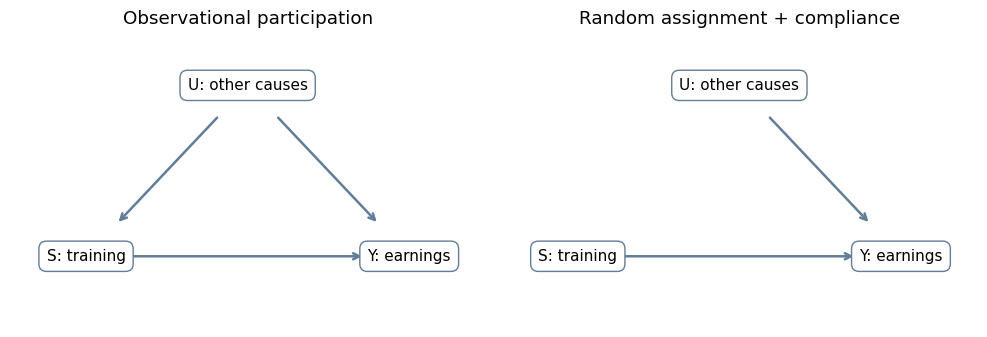

In [2]:
# Two small causal diagrams, drawn with Matplotlib (no Graphviz installation).
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
positions = {"U": (0.50, 0.82), "S": (0.16, 0.24), "Y": (0.84, 0.24)}
labels = {"U": "U: other causes", "S": "S: training", "Y": "Y: earnings"}
for ax, randomized in zip(axes, [False, True]):
    edges = [("S", "Y"), ("U", "Y")]
    if not randomized:
        edges.append(("U", "S"))
    for a, b in edges:
        ax.annotate("", xy=positions[b], xytext=positions[a],
                    arrowprops={"arrowstyle": "->", "lw": 1.8,
                                "color": "#627D98", "shrinkA": 32, "shrinkB": 34})
    for name, xy in positions.items():
        ax.text(*xy, labels[name], ha="center", va="center",
                bbox={"boxstyle": "round,pad=0.5", "fc": "white", "ec": "#627D98"})
    ax.set(xlim=(0, 1), ylim=(0, 1),
           title="Random assignment + compliance" if randomized else "Observational participation")
    ax.axis("off")
plt.tight_layout()
plt.show()


### Parameter → identification → estimation
The population **average treatment effect** is

$$\tau=\mathbb E[Y(1)-Y(0)].$$

It compares interventions on the **same target population**. It is not defined as the observed difference between two groups.

For the introductory experiment, assume:

1. **Random assignment and perfect compliance:** $S\perp (Y(0),Y(1))$.
2. **Both arms are possible:** $0<P(S=1)<1$.
3. **Well-defined outcomes:** no interference between units and no hidden treatment versions (SUTVA).

Then, for $s\in\{0,1\}$,

$$\mathbb E[Y(s)\mid S=s]
=\mathbb E[Y(s)],$$

Consequently,

$$\tau=\mathbb E[Y(1)\mid S=1]-\mathbb E[Y(0)\mid S=0].$$

**Randomization balances potential outcomes in distribution, not observed outcomes.** Observed earnings can differ because training has an effect. Realized baseline characteristics can differ by chance.

For a fixed set of $N$ participants, define the **finite-sample causal effect** and the **difference-in-means estimator** as

$$\tau_N=\frac{1}{N}\sum_{i=1}^N[Y_i(1)-Y_i(0)],
\qquad \widehat\tau=\overline Y_1-\overline Y_0.$$

Here, $\overline Y_s$ is the observed sample mean in arm $s$.

| Object | Meaning |
|:--|:--|
| Population parameter | Expectation over a specified target population |
| Finite-sample causal effect | Average causal effect for these participants |
| Estimator | Rule for comparing the observed treatment and control sample means |
| Realized estimate | The number obtained by applying that rule to one dataset |


### A synthetic experiment where the truth is visible
Construct both potential outcomes **before** assigning treatment. Earnings without training vary across people; training adds 1,000 units for every person in this deliberately simple simulation. Treatment is not the only cause of earnings.


In [13]:
rng_trial = np.random.default_rng(204)
N = 400
potential_y0 = rng_trial.normal(loc=20_000, scale=5_000, size=N)
potential_y1 = potential_y0 + 1_000
true_tau_N = np.mean(potential_y1 - potential_y0)

S = np.zeros(N, dtype=int)
S[rng_trial.choice(N, size=N // 2, replace=False)] = 1
observed_y = np.where(S == 1, potential_y1, potential_y0)
trial = pd.DataFrame({"S": S, "Y": observed_y})

trial_estimate = trial.loc[trial.S == 1, "Y"].mean() - trial.loc[trial.S == 0, "Y"].mean()
baseline_gap = potential_y0[S == 1].mean() - potential_y0[S == 0].mean()
display(pd.Series({
    "True finite-sample effect": true_tau_N,
    "Observed difference in means": trial_estimate,
    "Chance difference in baseline potential earnings": baseline_gap,
}, name="Synthetic earnings units").round(2).to_frame())

# This identity is available only because the simulation reveals both outcomes.
assert np.isclose(trial_estimate, true_tau_N + baseline_gap)


,Synthetic earnings units
True finite-sample effect,1000.00
Observed difference in means,1687.39
Chance difference in baseline potential earnings,687.39


### Exercise 1: what did randomization guarantee?
Why can the observed difference differ from 1,000? If training were more attractive to people with low baseline earnings, would a very large sample automatically fix the comparison?

<details><summary>Answer</summary>
<p>The treated and control participants have different baseline earnings by chance. In this constant-effect simulation, the estimate equals 1,000 plus that baseline gap. Across all possible complete randomizations, the expected gap is zero. This is a statement about repeated assignments, not exact equality in a realized dataset.</p>
<p>Self-selection can create a systematic baseline gap. Increasing the sample size can make an observational estimate more precise without removing that bias. Randomization is valuable because of how assignment is generated.</p>
</details>


## 2. NSW job training: estimation and uncertainty
### Real historical data
We retain the National Supported Work example from 2025. The supplied file contains the **LaLonde male experimental sample**, with **297 treated and 425 control observations**, not the smaller Dehejia–Wahba subset or a dataset with observational controls. See [Dehejia's data documentation](https://users.nber.org/~rdehejia/nswdata2.html).

| Variable | Meaning in the supplied file |
|:--|:--|
| `treat` | Experimental treatment-group indicator (1 = treated arm) |
| `re78` | Annual earnings in 1978, the outcome |
| `re75` | Annual earnings in 1975, a baseline covariate |
| `age`, `education` | Age and years of education |
| `black`, `hispanic`, `married`, `nodegree` | Historical binary demographic and education indicators |
| `data_id` | Sample label |

We use `treat` as the supplied experimental group label. The file does not separately record assignment and actual attendance, so it cannot establish perfect compliance. The randomized comparison concerns assignment to the program; interpreting it as the effect of **receiving** training additionally requires perfect compliance. Keep the historical demographic labels in their data context, not as claims about biological categories.


In [14]:
data_candidates = [Path("../data/nsw.dta"), Path("data/nsw.dta"), Path("nsw.dta")]
data_path = next((p for p in data_candidates if p.is_file()), None)
if data_path is None:
    raise FileNotFoundError(
        "Upload the supplied nsw.dta in Colab's Files sidebar, or keep the "
        "repository's data/ folder beside labs/. Then run this cell again."
    )

nsw = pd.read_stata(data_path)
# Use float64 for the calculations; the Stata earnings columns are float32.
nsw[["re75", "re78"]] = nsw[["re75", "re78"]].astype(float)
assert nsw.shape == (722, 10)
assert nsw["treat"].value_counts().to_dict() == {0: 425, 1: 297}
assert not nsw.isna().any().any()
print(f"Loaded {len(nsw)} historical observations from {data_path}.")
display(nsw.head())


Loaded 722 historical observations from nsw.dta.


,data_id,treat,age,education,black,hispanic,married,nodegree,re75,re78
0,Lalonde Sample,1,37,11,1,0,1,1,0.0,9930.045898
1,Lalonde Sample,1,22,9,0,1,0,1,0.0,3595.894043
2,Lalonde Sample,1,30,12,1,0,0,0,0.0,24909.449219
3,Lalonde Sample,1,27,11,1,0,0,1,0.0,7506.145996
4,Lalonde Sample,1,33,8,1,0,0,1,0.0,289.789886


### The difference-in-means estimator
Let $n_1$ and $n_0$ be the arm sizes. For each arm $s$, compute its sample mean and sample variance:

$$\overline Y_s=\frac{1}{n_s}\sum_{i:S_i=s}Y_i,
\qquad s_s^2=\frac{1}{n_s-1}\sum_{i:S_i=s}(Y_i-\overline Y_s)^2.$$

The estimate is $\widehat\tau=\overline Y_1-\overline Y_0$. This calculation uses **observed earnings only**. We never estimate a person's unobserved potential outcome or substitute a made-up $\widehat U$.


In [15]:
arm_summary = nsw.groupby("treat")["re78"].agg(n="size", mean="mean", sd="std")
arm_summary.index = ["Control (0)", "Treated (1)"]
display(arm_summary.round(2))

earnings_1 = nsw.loc[nsw.treat == 1, "re78"].to_numpy()
earnings_0 = nsw.loc[nsw.treat == 0, "re78"].to_numpy()
tau_hat = earnings_1.mean() - earnings_0.mean()
print(f"Estimated earnings difference: {tau_hat:,.2f} dollars.")


,n,mean,sd
Control (0),425,5090.05,5718.09
Treated (1),297,5976.35,6923.80


Estimated earnings difference: 886.30 dollars.


### How uncertain is the estimate?
We use the conventional **Welch two-sample approximation**, allowing different outcome variances in the two arms:

$$\widehat{SE}(\widehat\tau)=\sqrt{\frac{s_1^2}{n_1}+\frac{s_0^2}{n_0}},
\qquad T=\frac{\widehat\tau-0}{\widehat{SE}(\widehat\tau)}.$$

Writing $v_s=s_s^2/n_s$, the Welch degrees of freedom are

$$\nu=\frac{(v_1+v_0)^2}{v_1^2/(n_1-1)+v_0^2/(n_0-1)}.$$

Our default question is **two-sided**: $H_0:\tau=0$ versus $H_1:\tau\ne0$. The p-value is approximately $2P(t_\nu\geq |T|)$; the 95% interval is $\widehat\tau\pm t_{\nu,0.975}\widehat{SE}$.

This is an independent-participant approximation, not an exact randomization test or a reconstruction of all features of the original trial design. Earnings are skewed, so the reference distribution is approximate.


,NSW comparison
Estimate (dollars),886.3037
Standard error (dollars),488.2045
Welch degrees of freedom,557.0617
t statistic,1.8154
Two-sided p-value,0.0700
95% CI lower (dollars),-72.6431
95% CI upper (dollars),1845.2505


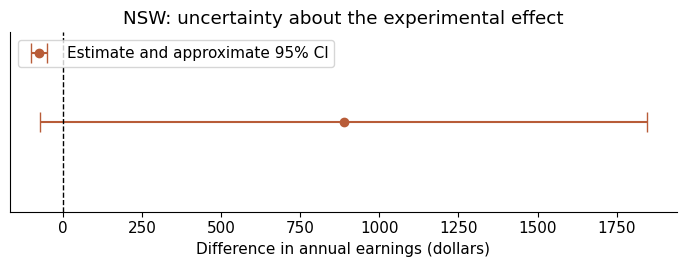

In [16]:
n1, n0 = len(earnings_1), len(earnings_0)
v1 = earnings_1.var(ddof=1) / n1
v0 = earnings_0.var(ddof=1) / n0
se = np.sqrt(v1 + v0)
welch_df = (v1 + v0)**2 / (v1**2 / (n1 - 1) + v0**2 / (n0 - 1))
t_stat = tau_hat / se
p_two = 2 * stats.t.sf(abs(t_stat), df=welch_df)
critical = stats.t.ppf(0.975, df=welch_df)
ci_low, ci_high = tau_hat - critical * se, tau_hat + critical * se

welch_check = stats.ttest_ind(earnings_1, earnings_0, equal_var=False)
assert np.allclose([t_stat, p_two], [welch_check.statistic, welch_check.pvalue])
display(pd.Series({
    "Estimate (dollars)": tau_hat,
    "Standard error (dollars)": se,
    "Welch degrees of freedom": welch_df,
    "t statistic": t_stat,
    "Two-sided p-value": p_two,
    "95% CI lower (dollars)": ci_low,
    "95% CI upper (dollars)": ci_high,
}, name="NSW comparison").round(4).to_frame())

fig, ax = plt.subplots(figsize=(7, 2.8))
ax.errorbar(tau_hat, 0, xerr=critical * se, fmt="o", capsize=7,
            color=COLORS["treatment"], label="Estimate and approximate 95% CI")
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set(yticks=[], xlabel="Difference in annual earnings (dollars)",
       title="NSW: uncertainty about the experimental effect")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


The estimated difference is about **886 dollars**, with a two-sided p-value near **0.070**. The 95% interval includes zero. At the 5% level, we fail to reject the two-sided null; this does not establish that the effect is zero.

The lecture instead asked whether the effect is **positive**, using a one-sided test. For the pre-specified directional question $H_0:\tau\leq0$ versus $H_1:\tau>0$ (calibrated at zero), the p-value is about **0.035**. Both calculations can be correct, because they answer different questions. Choose the direction before inspecting results.

The interval describes uncertainty about an average effect, not the spread of individual earnings or effects. Under the inference assumptions, repeated use of the procedure gives approximately 95% coverage; it does not assign a 95% probability to a fixed parameter after observing this interval.


In [17]:
p_greater = stats.ttest_ind(
    earnings_1, earnings_0, equal_var=False, alternative="greater"
).pvalue
display(pd.DataFrame({
    "Alternative": ["Effect differs from zero", "Effect is positive (pre-specified)"],
    "p-value": [p_two, p_greater],
    "Reject at 5%?": [p_two < 0.05, p_greater < 0.05],
}).round(4))


,Alternative,p-value,Reject at 5%?
0,Effect differs from zero,0.070,False
1,Effect is positive (pre-specified),0.035,True


### Exercise 2: interpret the result
1. Does a p-value of 0.070 mean there is a 7% chance that the null is true?
2. Why does the 95% two-sided interval include zero even though the one-sided p-value is below 0.05?
3. Can we infer that every participant gained 886 dollars?

<details><summary>Answer</summary>
<ol><li>No. Under the null and the test's assumptions, it is the approximate probability of a test statistic at least as extreme in either direction as the observed one.</li><li>A 95% two-sided interval corresponds to a 5% <strong>two-sided</strong> test. A 5% one-sided test allocates its rejection probability to one tail. It corresponds to a one-sided confidence bound, not this two-sided interval.</li><li>No. The estimate concerns an average experimental effect. Individual effects may vary, and the same person's two potential earnings outcomes are never jointly observed here.</li></ol>
</details>


## 3. What balance checks can tell us
A baseline covariate $X$ is measured before treatment. We compare baseline means and distributions to describe the realized groups and help detect possible implementation or data problems.

The **standardized mean difference** (SMD) is

$$\operatorname{SMD}(X)=\frac{\overline X_1-\overline X_0}
{\sqrt{(s_{X,1}^2+s_{X,0}^2)/2}}.$$

It expresses a difference in units of baseline variability. For binary indicators, the mean is a proportion. These tests assess means, not equality of entire distributions.

**Neither a small SMD nor a large p-value proves independence.** Unobserved variables remain unobserved, and multiple baseline tests can yield small p-values by chance. Randomization is justified by the assignment procedure and its implementation, not by obtaining a preferred balance table. Do not compare the post-treatment outcome as if it were a baseline balance variable.


,Control mean,Treated mean,SMD,Welch p-value
Covariate,,,,
age,24.447,24.626,0.027,0.722
education,10.188,10.380,0.112,0.144
black,0.800,0.801,0.003,0.965
hispanic,0.113,0.094,-0.061,0.415
married,0.158,0.168,0.029,0.703
nodegree,0.814,0.731,-0.200,0.009
re75,3026.683,3066.098,0.008,0.917


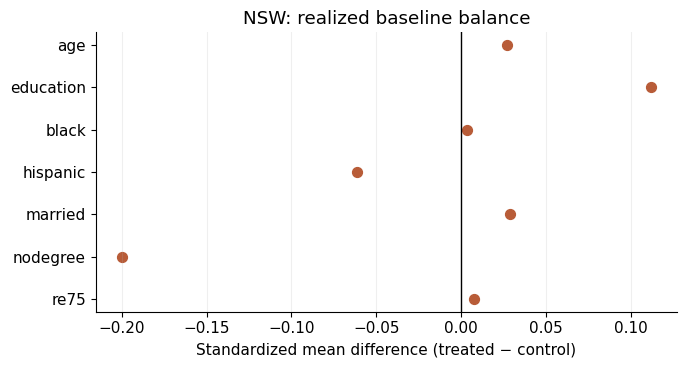

In [18]:
covariates = ["age", "education", "black", "hispanic", "married", "nodegree", "re75"]
balance_rows = []
for variable in covariates:
    x1 = nsw.loc[nsw.treat == 1, variable].astype(float)
    x0 = nsw.loc[nsw.treat == 0, variable].astype(float)
    scale = np.sqrt((x1.var(ddof=1) + x0.var(ddof=1)) / 2)
    balance_rows.append({
        "Covariate": variable,
        "Control mean": x0.mean(),
        "Treated mean": x1.mean(),
        "SMD": (x1.mean() - x0.mean()) / scale,
        "Welch p-value": stats.ttest_ind(x1, x0, equal_var=False).pvalue,
    })
balance_table = pd.DataFrame(balance_rows).set_index("Covariate")
display(balance_table.round(3))

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.scatter(balance_table["SMD"], balance_table.index, color=COLORS["treatment"], s=50)
ax.axvline(0, color="black", linewidth=1)
ax.set(xlabel="Standardized mean difference (treated − control)",
       title="NSW: realized baseline balance")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()


### Exercise 3: diagnose without overclaiming
Inspect `nodegree` in the table. Does a baseline p-value below 0.05 prove that randomization failed? Would all p-values above 0.05 prove that unmeasured motivation is balanced?

<details><summary>Answer</summary>
<p>Neither conclusion follows. The realized proportion without a degree differs across the groups. A small p-value can occur under valid randomization, particularly when examining several covariates; it can motivate checking assignment records, data coding, and the magnitude of the difference. It is not by itself proof of a broken experiment.</p>
<p>Conversely, failing to reject equal observed means does not establish their equality, equality of full distributions, or independence from unmeasured motivation. Design evidence is essential. Covariate adjustment can sometimes improve precision, but it does not turn a balance table into proof of randomization.</p>
</details>


## 4. Imperfect compliance and intention to treat
Let **$Z$ be randomized assignment** (an offer of training) and **$S$ be training actually received**. Perfect compliance means **$S_i=Z_i$ for every participant**. Equal treatment and assignment proportions are insufficient: different people could switch arms while the totals remain the same.

With imperfect compliance, motivation may affect both attendance and earnings:

$$Z\longrightarrow S\longrightarrow Y,\qquad U\longrightarrow S,\qquad U\longrightarrow Y.$$

Randomization protects the comparison by $Z$; it does not generally protect a comparison by $S$. Dropping noncompliers or comparing attendees with nonattendees can reintroduce selection bias.

Define $Y_i^Z(z)$ as the outcome under assignment $z$, allowing receipt to respond to that assignment. The **intention-to-treat effect** is

$$\tau_{\mathrm{ITT}}=\mathbb E[Y^Z(1)-Y^Z(0)].$$

Under randomized assignment, well-defined assignment interventions, no interference, and complete outcome observation,

$$\tau_{\mathrm{ITT}}=\mathbb E[Y\mid Z=1]-\mathbb E[Y\mid Z=0].$$

ITT answers the policy question: **what is the effect of offering the program?** It remains meaningful even if not everyone accepts. Estimating it does not require assuming that assignment affects outcomes only through receipt.


### A separate synthetic noncompliance example
Here, more motivated people have higher baseline earnings and are more likely to accept an offer. Controls cannot access the program. We generate each person's willingness, potential receipt, and potential outcomes **before** randomizing the offer.

For this simulation only, training adds 2,000 units and an offer has no direct effect on earnings. Thus $Y_i^Z(z)=Y_i(S_i(z))$. We do **not** create retrospective assignment labels for the NSW participants.


In [19]:
rng_compliance = np.random.default_rng(205)
N_offer = 2_000
motivation = rng_compliance.normal(size=N_offer)
baseline = 20_000 + 4_000 * motivation + rng_compliance.normal(0, 2_000, N_offer)
acceptance_probability = 1 / (1 + np.exp(-motivation))
willing = rng_compliance.binomial(1, acceptance_probability)

# Potential receipt and assignment-level outcomes, fixed before randomization.
receipt_if_no_offer = np.zeros(N_offer, dtype=int)
receipt_if_offer = willing
effect_of_receipt = 2_000
outcome_if_no_offer = baseline + effect_of_receipt * receipt_if_no_offer
outcome_if_offer = baseline + effect_of_receipt * receipt_if_offer
true_itt_N = np.mean(outcome_if_offer - outcome_if_no_offer)

Z = np.zeros(N_offer, dtype=int)
Z[rng_compliance.choice(N_offer, size=N_offer // 2, replace=False)] = 1
S_received = np.where(Z == 1, receipt_if_offer, receipt_if_no_offer)
Y_offer = np.where(Z == 1, outcome_if_offer, outcome_if_no_offer)
offers = pd.DataFrame({"Z": Z, "S": S_received, "Y": Y_offer})
display(pd.crosstab(offers["Z"], offers["S"],
                    rownames=["Assignment Z"], colnames=["Receipt S"]))


Receipt S,0,1
Assignment Z,,
0,1000,0
1,491,509


In [20]:
itt_hat = offers.loc[offers.Z == 1, "Y"].mean() - offers.loc[offers.Z == 0, "Y"].mean()
as_treated = offers.loc[offers.S == 1, "Y"].mean() - offers.loc[offers.S == 0, "Y"].mean()
display(pd.Series({
    "True finite-sample effect of receipt": effect_of_receipt,
    "True finite-sample effect of an offer (ITT)": true_itt_N,
    "Estimated ITT (compare Z)": itt_hat,
    "As-treated difference (compare S)": as_treated,
}, name="Synthetic earnings units").round(2).to_frame())
print(f"Fraction who would accept an offer: {willing.mean():.3f}")
assert np.isclose(true_itt_N, effect_of_receipt * willing.mean())


,Synthetic earnings units
True finite-sample effect of receipt,2000.00
True finite-sample effect of an offer (ITT),1020.00
Estimated ITT (compare Z),1044.86
As-treated difference (compare S),4041.46


Fraction who would accept an offer: 0.510


### Exercise 4: which comparison answers which question?
1. Why is the true ITT smaller than 2,000 in this simulation?
2. Why does the as-treated comparison fail to isolate the effect of receipt?
3. If an offered participant declines training but their earnings are recorded, should they stay in the offered arm for ITT?

<details><summary>Answer</summary>
<ol><li>Only willing participants change their receipt status when offered training. In this specific model, the finite-sample ITT equals 2,000 times the fraction willing. This relationship relies on the simulation's constant receipt effect and lack of a direct offer effect; it is not a universal formula.</li><li>Attendees are selected partly by motivation, which also raises baseline earnings. Receipt was not randomized. The comparison by assignment preserves the experimental design.</li><li>Yes. Analyze people according to their original assignment and retain recorded outcomes regardless of compliance. Nonattendance and a missing outcome are different problems. ITT does not automatically repair bias caused by missing outcomes.</li></ol>
<p>Effects among compliers require additional assumptions and instrumental-variable methods, which are deferred to later labs.</p>
</details>


## 5. Spillovers and treatment versions
**SUTVA** (stable unit treatment value assumption) means that (in this class):

- **No interference:** one person's outcome does not depend on other people's treatment assignments.


### Tutoring and peer learning
If tutored students share what they learn with untreated classmates, a student's outcome may be $Y_i(s_i,\mathbf s_{-i})$, depending on their own treatment and everyone else's. Writing only $Y_i(1)$ and $Y_i(0)$ hides that dependence.

An individual randomized comparison may still answer a question about a particular assignment policy, but it is not automatically the effect of tutoring one student while leaving everyone else unaffected. Nor is it automatically the effect of tutoring the whole school.

One option is to randomize **schools** to offer tutoring to all students. If there is no interference **between** schools, define a school's mean outcome under that policy as $\overline Y_g(z)$ and target

$$\tau_{\mathrm{school}}=\frac{1}{G}\sum_{g=1}^G
\left[\overline Y_g(1)-\overline Y_g(0)\right].$$

This is an equally weighted average over schools, including within-school spillovers. Analyze the school assignment units when quantifying uncertainty. With unequal school sizes, an average over schools and an average over students are different targets. The optional exercise implements an equal-sized-school example.


### Exercise 5: choose the experimental unit
A tutoring program is randomized by classroom. Students share notes within classrooms and also with friends in other classrooms. What assumption would justify an analysis of classroom means?

<details><summary>Answer</summary>
<p>A simple classroom-level analysis requires no relevant interference between classrooms, alongside randomized assignment, a well-defined classroom intervention, and outcome observation. Within-classroom spillovers can be part of the classroom policy effect. Cross-classroom sharing threatens the no-between-classroom-interference assumption; assigning larger groups may help if spillovers are contained within those groups, or the design must explicitly model cross-group exposure.</p>
</details>


## 6. Limits of experiments
Randomization addresses systematic confounding of **assignment**, but a useful experiment also needs:

- **Outcome follow-up:** differential attrition can bias an analysis restricted to observed outcomes.
- **Implementation and measurement:** record assignment, actual receipt, treatment versions, and outcomes consistently. Behavior may change when participants know they are being studied.
- **Enough independent assignment units:** a large number of students in a handful of randomized schools does not create a large number of randomized schools.
- **A relevant target population and setting:** an internally valid experimental effect need not transfer to a different population, period, or delivery system.
- **Feasibility and ethical design:** cost, time, and the intervention's acceptability can constrain what can be randomized.




## Optional. Randomize schools, analyze schools
In this **synthetic** model, each school has 30 students. If fraction $q_g$ of a student's *other classmates* receive tutoring, the student's score is

$$Y_{ig}=Y_{ig}(0,0)+4s_{ig}+2q_g.$$

The direct contribution is 4 points and the peer contribution is 2 points at full peer treatment. Assigning an entire school to tutoring changes both terms, so the all-treated versus all-control policy effect is 6 points. Assume full compliance, a common tutoring version, and no spillovers between schools.

We create baseline student scores and both school-level potential means first. Then we randomize 20 of 40 schools. The target is the average policy effect across these schools. Since schools have equal size here, it also equals the average across their students.


In [21]:
rng_school = np.random.default_rng(207)
G, students_per_school = 40, 30
school_component = rng_school.normal(0, 5, size=G)
baseline_scores = (60 + school_component[:, None]
                   + rng_school.normal(0, 8, size=(G, students_per_school)))
school_y0 = baseline_scores.mean(axis=1)
school_y1 = (baseline_scores + 4 + 2).mean(axis=1)

Z_school = np.zeros(G, dtype=int)
Z_school[rng_school.choice(G, size=G // 2, replace=False)] = 1
schools = pd.DataFrame({
    "school": np.arange(G),
    "Z": Z_school,
    "mean_score": np.where(Z_school == 1, school_y1, school_y0),
})
display(schools.groupby("Z")["mean_score"].agg(schools="size", mean="mean", sd="std").round(2))

score_1 = schools.loc[schools.Z == 1, "mean_score"].to_numpy()
score_0 = schools.loc[schools.Z == 0, "mean_score"].to_numpy()
school_estimate = score_1.mean() - score_0.mean()
school_v1 = score_1.var(ddof=1) / len(score_1)
school_v0 = score_0.var(ddof=1) / len(score_0)
school_se = np.sqrt(school_v1 + school_v0)
school_df = (school_v1 + school_v0)**2 / (
    school_v1**2 / (len(score_1) - 1) + school_v0**2 / (len(score_0) - 1)
)
school_margin = stats.t.ppf(0.975, school_df) * school_se
print(f"True finite-school policy effect: {np.mean(school_y1 - school_y0):.2f} points")
print(f"Estimated policy effect: {school_estimate:.2f} points")
print(f"Approximate 95% CI: [{school_estimate - school_margin:.2f}, "
      f"{school_estimate + school_margin:.2f}]")
print(f"Welch degrees of freedom at the school level: {school_df:.1f}")
assert np.allclose(school_y1 - school_y0, 6)


,schools,mean,sd
Z,,,
0,20,61.18,5.03
1,20,67.15,5.76


True finite-school policy effect: 6.00 points
Estimated policy effect: 5.97 points
Approximate 95% CI: [2.50, 9.43]
Welch degrees of freedom at the school level: 37.3


### Optional exercise: what effect did we estimate?
Why is the target 6 rather than 4? Why does the analysis use 40 school means instead of treating 1,200 student outcomes as independently assigned?

<details><summary>Answer</summary>
<p>The intervention gives tutoring to an entire school, changing both own treatment and peer exposure. Its effect in this model is 4 direct points plus 2 peer points. The contrast does not isolate the direct effect while holding peers untreated.</p>
<p>Assignment happens at the school level, and students in a school share both assignment and a school component. Treating students as independent assignment units ignores that dependence and can substantially understate uncertainty. Here we use a Welch approximation on school means. With fewer schools, its approximation deserves particular caution; with unequal sizes, weighting must also match the desired target.</p>
</details>


---
## Sources and attribution
[Dehejia's data page](https://users.nber.org/~rdehejia/nswdata2.html) documents the LaLonde experimental sample and distributes the data for attributable non-commercial use (CC BY-NC). The current lab analyzes this supplied file; its simulations are separate.

Data references requested by that archive:

- LaLonde, R. J. (1986). *Evaluating the Econometric Evaluations of Training Programs with Experimental Data.* American Economic Review, 76(4), 604–620.
- Dehejia, R. H., and Wahba, S. (1999). *Causal Effects in Nonexperimental Studies: Reevaluating the Evaluation of Training Programs.* Journal of the American Statistical Association, 94(448), 1053–1062.
- Dehejia, R. H., and Wahba, S. (2002). *Propensity Score Matching Methods for Nonexperimental Causal Studies.* Review of Economics and Statistics, 84(1), 151–161.

The optional simulations illustrate concepts; they do not reproduce findings from these papers.
